# **Task 4**

## **DJS Synapse Learning Period**
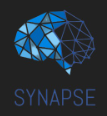

Congratulations on making it this far!! Welcome to the world of classification where we move on from unsupervised to helping the algorithms by telling them exactly what the data we're feeding them is. This week we'll be looking into  many algorithms such as Decision Trees, SVC, Naive Bayes, Random Forest and so on. We'll also be delving into hyperparameter tuning the only place where ched chaad can lead to a good result.

**Warning: This task contains many theory questions. Proceed with caution!**

Jk, make sure you research well and make sure you are understanding the models y'all are implementing as that will make your concepts much stronger and build a strong ML foundation which will be very useful as we move further with the tasks.

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

## Importing the dataset

Use this link to download the adult income dataset and upload it to your drive.

https://drive.google.com/file/d/1VAE1qF16D-sKnBOWXzGXVNGhtNZNLFQS/view?usp=sharing

In [74]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
#import your dataset here
from google.colab import files
uploaded = files.upload()

Saving adult_income_dataset.csv to adult_income_dataset (4).csv


In [75]:
import pandas as pd
df = pd.read_csv('adult_income_dataset.csv')

## Dealing with Nan values

In [76]:
df.shape

(32561, 15)

In [77]:
#write a code to find the nan values for the dataset and make a decision on whether to dropna or fill na
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [78]:
df.dropna(inplace=True)

## Object Valued Columns

For Relationship, Race and Sex find out the max division average fnlwgt for each unique value.

In [79]:
#Write your code here
print(df.groupby('relationship')['fnlwgt'].mean().max())
print(df.groupby('race')['fnlwgt'].mean().max())
print(df.groupby('sex')['fnlwgt'].mean().max())

206017.29921259842
228807.4554490593
191650.24607458292


## Getting rid of unnecessary columns

*   Drop the education num column since we already have their education in the form of categories
*   Check the combinations of the marital-status and relationship column, see if we need both of them or just marital status will work too.


In [80]:
#write your code here
df.drop('education-num',axis=1,inplace=True)

In [81]:
pd.crosstab(df['marital-status'],df['relationship'])

relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
marital-status,,,,,,
Divorced,0,2268,103,308,1535,0
Married-AF-spouse,9,0,1,1,0,10
Married-civ-spouse,12454,14,118,83,0,1396
Married-spouse-absent,0,181,26,43,120,0
Never-married,0,4448,548,3929,801,0
Separated,0,383,53,90,413,0
Widowed,0,432,40,12,343,0


In [84]:
df.drop('marital-status',axis=1,inplace=True)

## Dealing with Categorical Data
As you probably know by now, the ML models dont know how to deal with String or object type data... so your mission shall you choose to accept it (don't really have much of a choice) is to find out which columns to do one hot encoding on and which columns to do Label Encoding on.

**Hint: Since Marital-status has less number of columns (distinct values na), One Hot encode it**

In [85]:
#Write your code here
#Hint: Check which needs one hot encoding which needs label encoding
#Then perform necessary transformations (Feel free to add more coding cells)
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['workclass', 'education', 'occupation', 'relationship', 'race', 'sex',
       'native-country', 'income'],
      dtype='object')

In [86]:
df = pd.get_dummies(df, columns=['relationship', 'sex', 'race', 'workclass', 'native-country'], drop_first=True)

In [87]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['occupation'] = le.fit_transform(df['occupation'])

## Altering the Target Column
Modify the Target Column (income) to make sure that all the values which are <=50K are replaced with a 0 and the values >50K are replaced with a 1.

In [88]:
#write your code here
df['income'] = df['income'].apply(lambda x: 0 if '<=50K' in x else 1)

**Extract the target column(income) and store it in a seperate variable and remove it from the original dataset. Additionally, do a 70:30 Train Test Split**

In [89]:
#write your code here
X = df.drop('income', axis=1)
y = df['income']

In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Chalo now that we have the preprocessed data we can feed it into the models. Lets start with some basic ones.

# Logistic Regression
*   Theory:https://www.youtube.com/watch?v=yIYKR4sgzI8&list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe
*   Implementation: https://www.youtube.com/watch?v=n40hS9tQmcY


Explain the algorithm, its working and its use cases.

In [91]:
#import the model and apply it to the data
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Find the accuracy and confusion matrix for the same and explain what it shows.

In [92]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
lr=round(accuracy_score(y_test, y_pred_lr),3)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr),3))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.787
[[6542  225]
 [1705  577]]
              precision    recall  f1-score   support

           0       0.79      0.97      0.87      6767
           1       0.72      0.25      0.37      2282

    accuracy                           0.79      9049
   macro avg       0.76      0.61      0.62      9049
weighted avg       0.77      0.79      0.75      9049



### Now that you have printed a confusion matrix and classification report. Let's see what you have understood from it. Write a short paragraph highlighting what you understoood from it below.

so for how LR works - till the calculation of y=wx+b its same as linear regression but after that y is passed through the sigmoid function and then depending on the seperating factor it will predict it as a zero or 1 then that will pass through the loss function and depending on the loss the weights of each features are changed to get an output.

from the confusion matrix the model correctly predicts the majority class which is zero and fails to correctly predict one

precision is high for 0 which means it correctly predicted 0 and vise verca for 1

For class 1, precision is lower at 0.69 and recall is very low at 0.37, meaning the model predicts class 1 somewhat accurately when it tries but misses a lot of actual class 1 instances.

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [93]:
#import the model from sklearn and apply it to your data
from sklearn.naive_bayes import MultinomialNB
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Make predictions
y_pred_nb = model_nb.predict(X_test)


# Calculate accuracy
nb=round(accuracy_score(y_test, y_pred_nb),3)
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb),3))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.772
[[6467  300]
 [1765  517]]
              precision    recall  f1-score   support

           0       0.79      0.96      0.86      6767
           1       0.63      0.23      0.33      2282

    accuracy                           0.77      9049
   macro avg       0.71      0.59      0.60      9049
weighted avg       0.75      0.77      0.73      9049



# Decision Tree Classifier
* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

In [96]:
#import the decision tree from sklearn and run it on your data
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)


<b>Print the Model Accuracy</b>

In [97]:
dt=round(accuracy_score(y_test, y_pred_dt),3)
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt),3))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.804
[[5851  916]
 [ 860 1422]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      6767
           1       0.61      0.62      0.62      2282

    accuracy                           0.80      9049
   macro avg       0.74      0.74      0.74      9049
weighted avg       0.81      0.80      0.80      9049



## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans:so for how LR works - till the calculation of y=wx+b its same as linear regression but after that y is passed through the sigmoid function and then depending on the seperating factor it will predict it as a zero or 1 then that will pass through the loss function and depending on the loss the weights of each features are changed to get an output.

for decision tree, it's basically like a 20 question game u keep asking question till u get your answer. the orser of these questions are decided by the gini impurity so which question and from which feature it is asked is based on that.

naive bayes basically uses probability and asks what is the probability of something happening if something else has actually occured, in our case that something already occured is the data in our features and about to happen is our target class which we are trying to predict


### Mention some real life use cases for each of these three models:

---



naive bayes - prediction system - predict a user's intrest based on previous choices

decision tree - banking - approving loan if a number of conditions are satisfied

logistic regression - in healthcare to predict if a tumour is malignant or notAns:

:Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

In [98]:
max_depth_values = [2, 3, 4, 5, 6]
min_samples_split_values = [2, 5, 10]
results_dt = []

In [99]:
for depth in max_depth_values:
    for min_split in min_samples_split_values:
        model = DecisionTreeClassifier(max_depth=depth, min_samples_split=min_split)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results_dt.append({'max_depth': depth, 'min_samples_split': min_split, 'accuracy': acc})

In [100]:
results_dt

[{'max_depth': 2, 'min_samples_split': 2, 'accuracy': 0.7895900099458504},
 {'max_depth': 2, 'min_samples_split': 5, 'accuracy': 0.7895900099458504},
 {'max_depth': 2, 'min_samples_split': 10, 'accuracy': 0.7895900099458504},
 {'max_depth': 3, 'min_samples_split': 2, 'accuracy': 0.7906951044314289},
 {'max_depth': 3, 'min_samples_split': 5, 'accuracy': 0.7906951044314289},
 {'max_depth': 3, 'min_samples_split': 10, 'accuracy': 0.7906951044314289},
 {'max_depth': 4, 'min_samples_split': 2, 'accuracy': 0.7922422367112388},
 {'max_depth': 4, 'min_samples_split': 5, 'accuracy': 0.7922422367112388},
 {'max_depth': 4, 'min_samples_split': 10, 'accuracy': 0.7922422367112388},
 {'max_depth': 5, 'min_samples_split': 2, 'accuracy': 0.811470880760305},
 {'max_depth': 5, 'min_samples_split': 5, 'accuracy': 0.811470880760305},
 {'max_depth': 5, 'min_samples_split': 10, 'accuracy': 0.811470880760305},
 {'max_depth': 6, 'min_samples_split': 2, 'accuracy': 0.8110288429660736},
 {'max_depth': 6, 'min_s

In [101]:
results_df = pd.DataFrame(results_dt)
print(results_df.sort_values(by='accuracy', ascending=False).head(10))

    max_depth  min_samples_split  accuracy
11          5                 10  0.811471
9           5                  2  0.811471
10          5                  5  0.811471
12          6                  2  0.811029
13          6                  5  0.811029
14          6                 10  0.811029
6           4                  2  0.792242
7           4                  5  0.792242
8           4                 10  0.792242
4           3                  5  0.790695


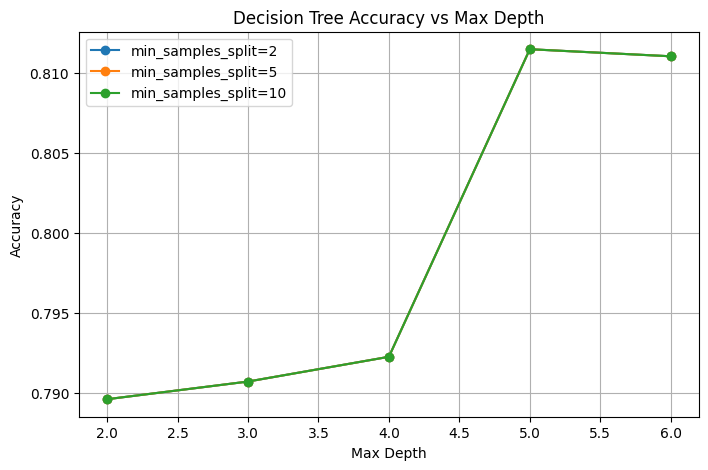

In [103]:
results_df = pd.DataFrame(results_dt)

depths = results_df['max_depth'].unique()
splits = sorted(results_df['min_samples_split'].unique())

plt.figure(figsize=(8,5))
for split in splits:
    accuracies = results_df[results_df['min_samples_split'] == split]['accuracy'].tolist()
    plt.plot(depths, accuracies, marker='o', label=f'min_samples_split={split}')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.grid(True)
plt.show()


In [104]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results_lr = []

for C in C_values:
        model = LogisticRegression(C=C)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results_lr.append({'C': C,'accuracy': acc})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

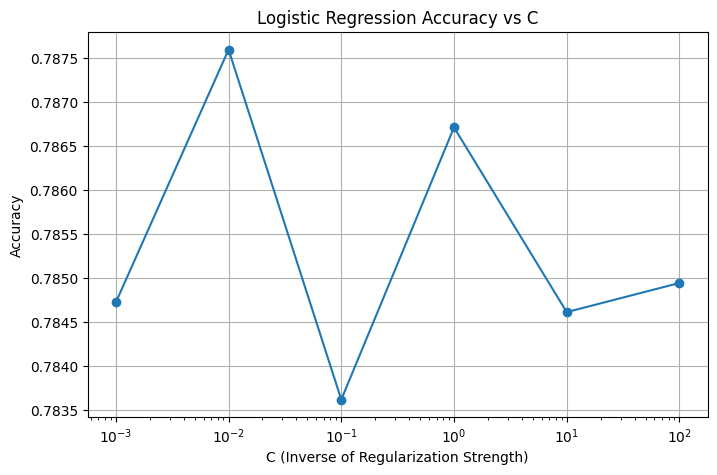

In [105]:
results_df = pd.DataFrame(results_lr)

plt.figure(figsize=(8,5))
plt.plot(results_df['C'], results_df['accuracy'], marker='o')
plt.xscale('log')  # use log scale because C spans multiple orders of magnitude
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy vs C')
plt.grid(True)
plt.show()

In [106]:
from sklearn.naive_bayes import MultinomialNB
alpha_values = [0.001, 0.01, 0.1, 1, 10]
results_nb = []

for a in alpha_values:
    model = MultinomialNB(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_nb.append({'alpha': a, 'accuracy': acc})

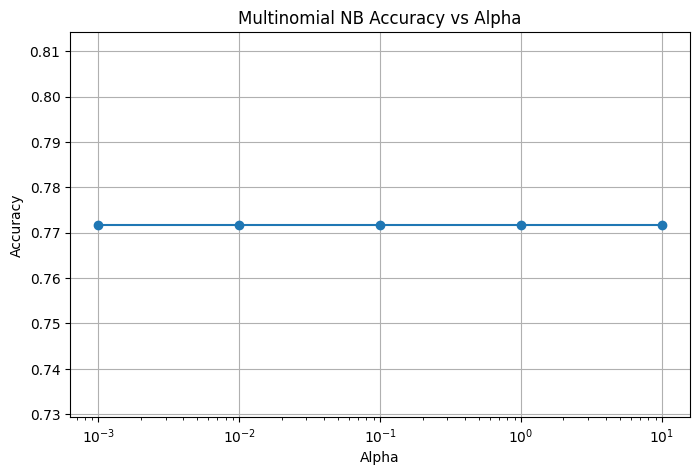

In [107]:
results_df = pd.DataFrame(results_nb)
plt.figure(figsize=(8,5))
plt.plot(results_df['alpha'], results_df['accuracy'], marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Multinomial NB Accuracy vs Alpha')
plt.grid(True)
plt.show()

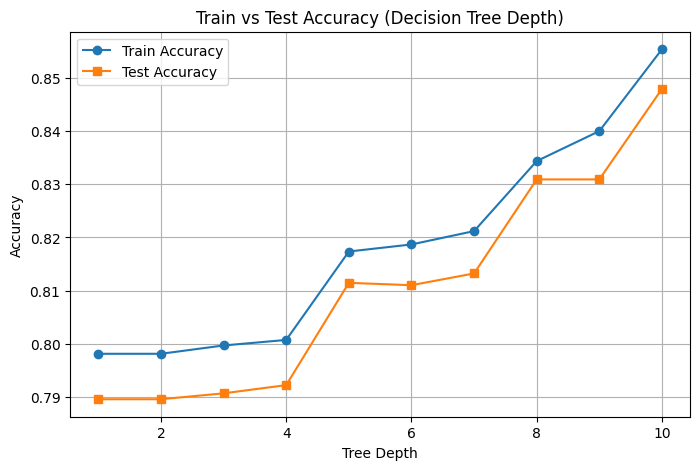

In [108]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)
train_acc = []
test_acc = []
depths = range(1, 11)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='s', label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train vs Test Accuracy (Decision Tree Depth)")
plt.grid(True)
plt.show()



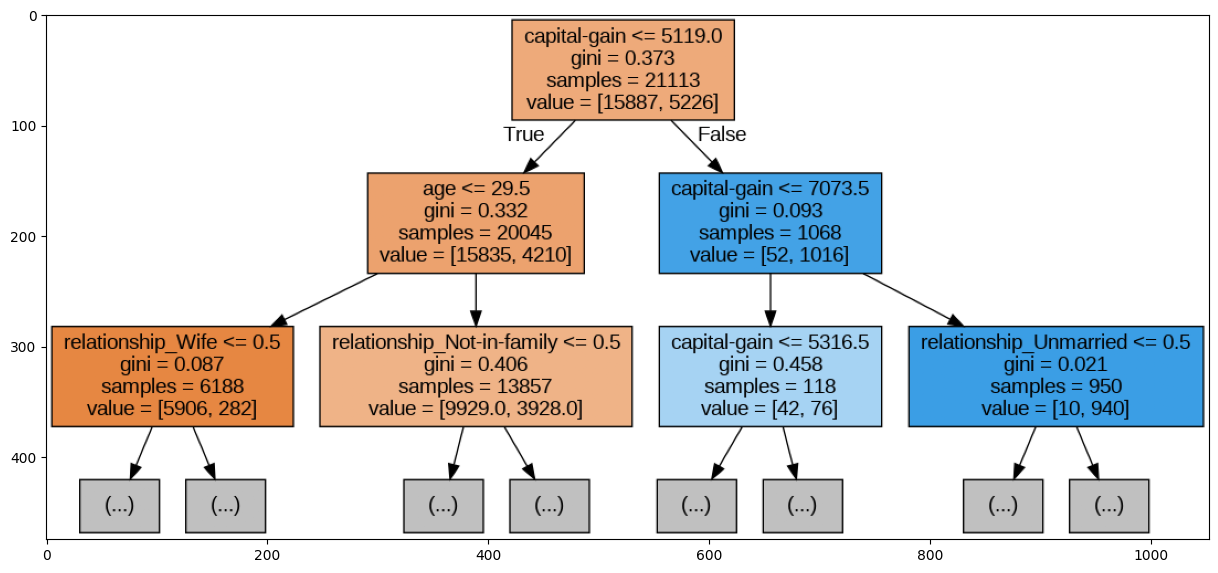

In [109]:
#complete the code below to create an image of the decision tree
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz(model_dt, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file
image = plt.imread('tree.png')
plt.figure(figsize=(15,15))
plt.imshow(image)

<b>print the test accuracy and train accuracy here</b>

In [ ]:
#write code here


[link text](https://)### Explain the different hyperparameters you changed and how did it affect the models. Also give a summary of the graphs you made.

Ans:for decision tree we changed the max depth and split and observed that split is not contributing to the model as much as tree depth and from the graph -as depth increased the accuracy also increased, is a general observation

for logistic regression we changed c which is the inverse of hyperparameter lambda used for regularization and from the graph we inferred that on increasing c we did not see any trend in accuracy and also at c = 0.01 the accuracy is highest

for naive bayes we change the hyperparameter alpha which adds a small value to prevent probabilities from becoming zero, from the graph we inferred that by chnaging alpha accuracy remained the same


\## SUPPORT VECTOR MACHINE (SVM)

Theory : https://www.youtube.com/watch?v=efR1C6CvhmE (Part 1)

Theory: https://www.youtube.com/watch?v=H9yACitf-KM

Maths Intuition : https://www.youtube.com/watch?v=Js3GLb1xPhc

EXTRAS:

https://www.youtube.com/watch?v=NDqACjz5j8g

If you are more curious and want to explore :

https://www.youtube.com/watch?v=Toet3EiSFcM (Part 2)

https://www.youtube.com/watch?v=efR1C6CvhmE&t=432s (Part 3)

https://www.youtube.com/watch?v=8bFKyb77vp0




In [110]:
#Now that we know SVM is sensitive to feature scales, so standardize (don't forget to standardise your X_test):
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [111]:
#Train your model
model_svm = SVC()
model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)

In [112]:
#Predict and check accuracies
from sklearn.metrics import accuracy_score
svm=round(accuracy_score(y_test, y_pred_svm),3)
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm),3))


Accuracy: 0.814


In [113]:
#let's try out using different kernels now. Freedom to choose lies in your hands. EXPLOREEE!
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    y_pred_train = svm_model.predict(X_train_scaled)
    y_pred_test = svm_model.predict(X_test_scaled)

    print(f"Kernel: {kernel}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
    print("-"*40)


Kernel: linear
Test Accuracy: 0.8077
----------------------------------------
Kernel: poly
Test Accuracy: 0.7812
----------------------------------------
Kernel: rbf
Test Accuracy: 0.8145
----------------------------------------
Kernel: sigmoid
Test Accuracy: 0.7826
----------------------------------------


## BIAS AND VARIANCE
### Hurrayy! You have made it so far sane.

### Before moving forward let's first understand what exactly do you mean by bias and variance.

THEORY: https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/ (explained in quite detail do read this not just video)

VIDEO: https://www.youtube.com/watch?v=EuBBz3bI-aA


## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [114]:
#implement Random forest
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)


# Make predictions on the test data
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model's performance
rf=round(accuracy_score(y_test, y_pred),3)
print("accuracy:",round(accuracy_score(y_test, y_pred),3))
# Optional: Generate a classification report for more details
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


accuracy: 0.851

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6767
           1       0.75      0.61      0.67      2282

    accuracy                           0.85      9049
   macro avg       0.81      0.77      0.79      9049
weighted avg       0.84      0.85      0.85      9049



In [115]:
#find the accuracy


### Explain the difference between random forest and decision tree. Also think of cases where the outputs for both of them can be same if its possible.

Ans :
for decision tree, it's basically like a 20 question game u keep asking question till u get your answer. the orser of these questions are decided by the gini impurity so which question and from which feature it is asked is based on that.

so the problem with decision tree is that it does not generalize, it asks questions to perfectly fit the training data leading to overfitting so it performs very well on training data but bad on testing data. that is where random forest comes in to decrease variance. it takes bootstrapped samples from all of the data makes a number of decision tress who have features randomly selected and asked questions on for the root node and for the consequent splits based on gini impurity or entropy loss, then all of these trees are trained on the samples and the majority vote is considered as the output



In [116]:
#write a code to implement BaggingClassifier
from sklearn.ensemble import BaggingClassifier



# Initialize the base estimator (e.g., Decision Tree)
base_estimator = DecisionTreeClassifier(random_state=42)

# Initialize the BaggingClassifier
bagging_model = BaggingClassifier(n_estimators=50,max_samples=1.0,max_features=1.0,bootstrap=True,random_state=42)

# Train the Bagging model
bagging_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = bagging_model.predict(X_test_scaled)

# Evaluate the model's performance
bg=round(accuracy_score(y_test, y_pred),3)
print("accuracy:",round(accuracy_score(y_test, y_pred),3))

# Optional: Generate a classification report for more details
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy: 0.845

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6767
           1       0.73      0.60      0.66      2282

    accuracy                           0.85      9049
   macro avg       0.80      0.77      0.78      9049
weighted avg       0.84      0.85      0.84      9049



### Explain how are Bagging and Random Forest different and why do we do bagging?


Ans :the only difference between bagging and random forest is the random feature selection that random forest does.

bagging is used when we want the feature selection, when we don't want it to be random. for eg if there is a dataset whose features have high corelation with the target class random feature slection will decrease the accuracy of the model so in those cases bagging tends to be better and the reason we use it

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
*   Theory:https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [117]:
#write code here
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
#yk the drill now
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
boosting_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
boosting_model.fit(X_train_scaled, y_train)
y_pred = boosting_model.predict(X_test_scaled)
ada=round(accuracy_score(y_test, y_pred),3)
print("accuracy:",round(accuracy_score(y_test, y_pred),3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      6767
           1       0.75      0.55      0.63      2282

    accuracy                           0.84      9049
   macro avg       0.81      0.74      0.77      9049
weighted avg       0.83      0.84      0.83      9049



# Just to make things more interesting implement XGBoost as well and compare its accuracy with that of AdaBoost :)

In [118]:
!pip install xgboost
import xgboost as xgb


In [119]:
from xgboost import XGBClassifier


In [120]:
xgb_model = XGBClassifier(n_estimators=50, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb=round(accuracy_score(y_test, y_pred_xgb),3)
print("accuracy:",round(accuracy_score(y_test, y_pred_xgb),3))
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))


accuracy: 0.871

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      6767
           1       0.79      0.66      0.72      2282

    accuracy                           0.87      9049
   macro avg       0.84      0.80      0.82      9049
weighted avg       0.87      0.87      0.87      9049



### Explain: What is the difference between Adaboost and XGBoost. Also describe in what cases is XGBoost better to use than AdaBoost.



```
# This is formatted as code
```

Ans : the basis of both is boosting in which we basically an extra step to random forest, after making all the different trees and boostrapped samples, in boosting every consequent tree focuses on the mistakes or misclassifications of the previous tree instead of random feature selection. one difference is that in adaboost the trees are shallow while they can be deep in xgboost. the main difference comes in the way in which they calculate loss and summarize the result from all the outputs of different decision tress. in adaboost the weighted average of all the outputs is taken and the weights are assigned based on the accuracy of each tree. in xgboost every next tree focuses on decreasing a diffrentiable loss function using gradient descent so each tree tries to minimize it, and the final answer is the additive sum of all the outputs. the main difference i think is that in ada the next tree is focused on the mistakes of the past tree and in xg it is not focused on the mistakes it just does what it has to do reduce the overall loss function.

in cases where the features and target class have complex relationships. also when the dataset is prone to overfitting as xg applies l1/l2 regularization

## Explain: What is the difference between Bagging and Boosting? Explain with examples

Ans: Bagging and boosting are both ensemble methods, but they work differently. In boosting, each tree is trained sequentially to correct the errors of all previous trees, and each tree's contribution is weighted based on its performance. The final prediction is a weighted combination or additive sum of all trees. Bagging, in contrast, trains all trees independently on random subsets and aggregates their predictions to reduce variance.








### 3. Pruning Techniques



*   Theory: https://opendatascience.com/what-is-pruning-in-machine-learning/
*   Theory:https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107



In [121]:
#implement pruning
pruned_tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
pruned_tree.fit(X_train_scaled, y_train)
y_pred = pruned_tree.predict(X_test_scaled)

pt=round(accuracy_score(y_test, y_pred),3)
print("accuracy:",round(accuracy_score(y_test, y_pred),3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy: 0.811

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      6767
           1       0.93      0.27      0.42      2282

    accuracy                           0.81      9049
   macro avg       0.87      0.63      0.65      9049
weighted avg       0.83      0.81      0.77      9049



In [122]:
#before plotting a tree you will need to first convert your X_train and X_test to DataFrame (Explain WHY (Hint: You made one tree before and it worked fine so it has to do with something you did after..Explore))
#Code to convert it here:

original_feature_names = X_train.columns.tolist()
X_train_scaled = pd.DataFrame(X_train_scaled, columns=original_feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=original_feature_names)

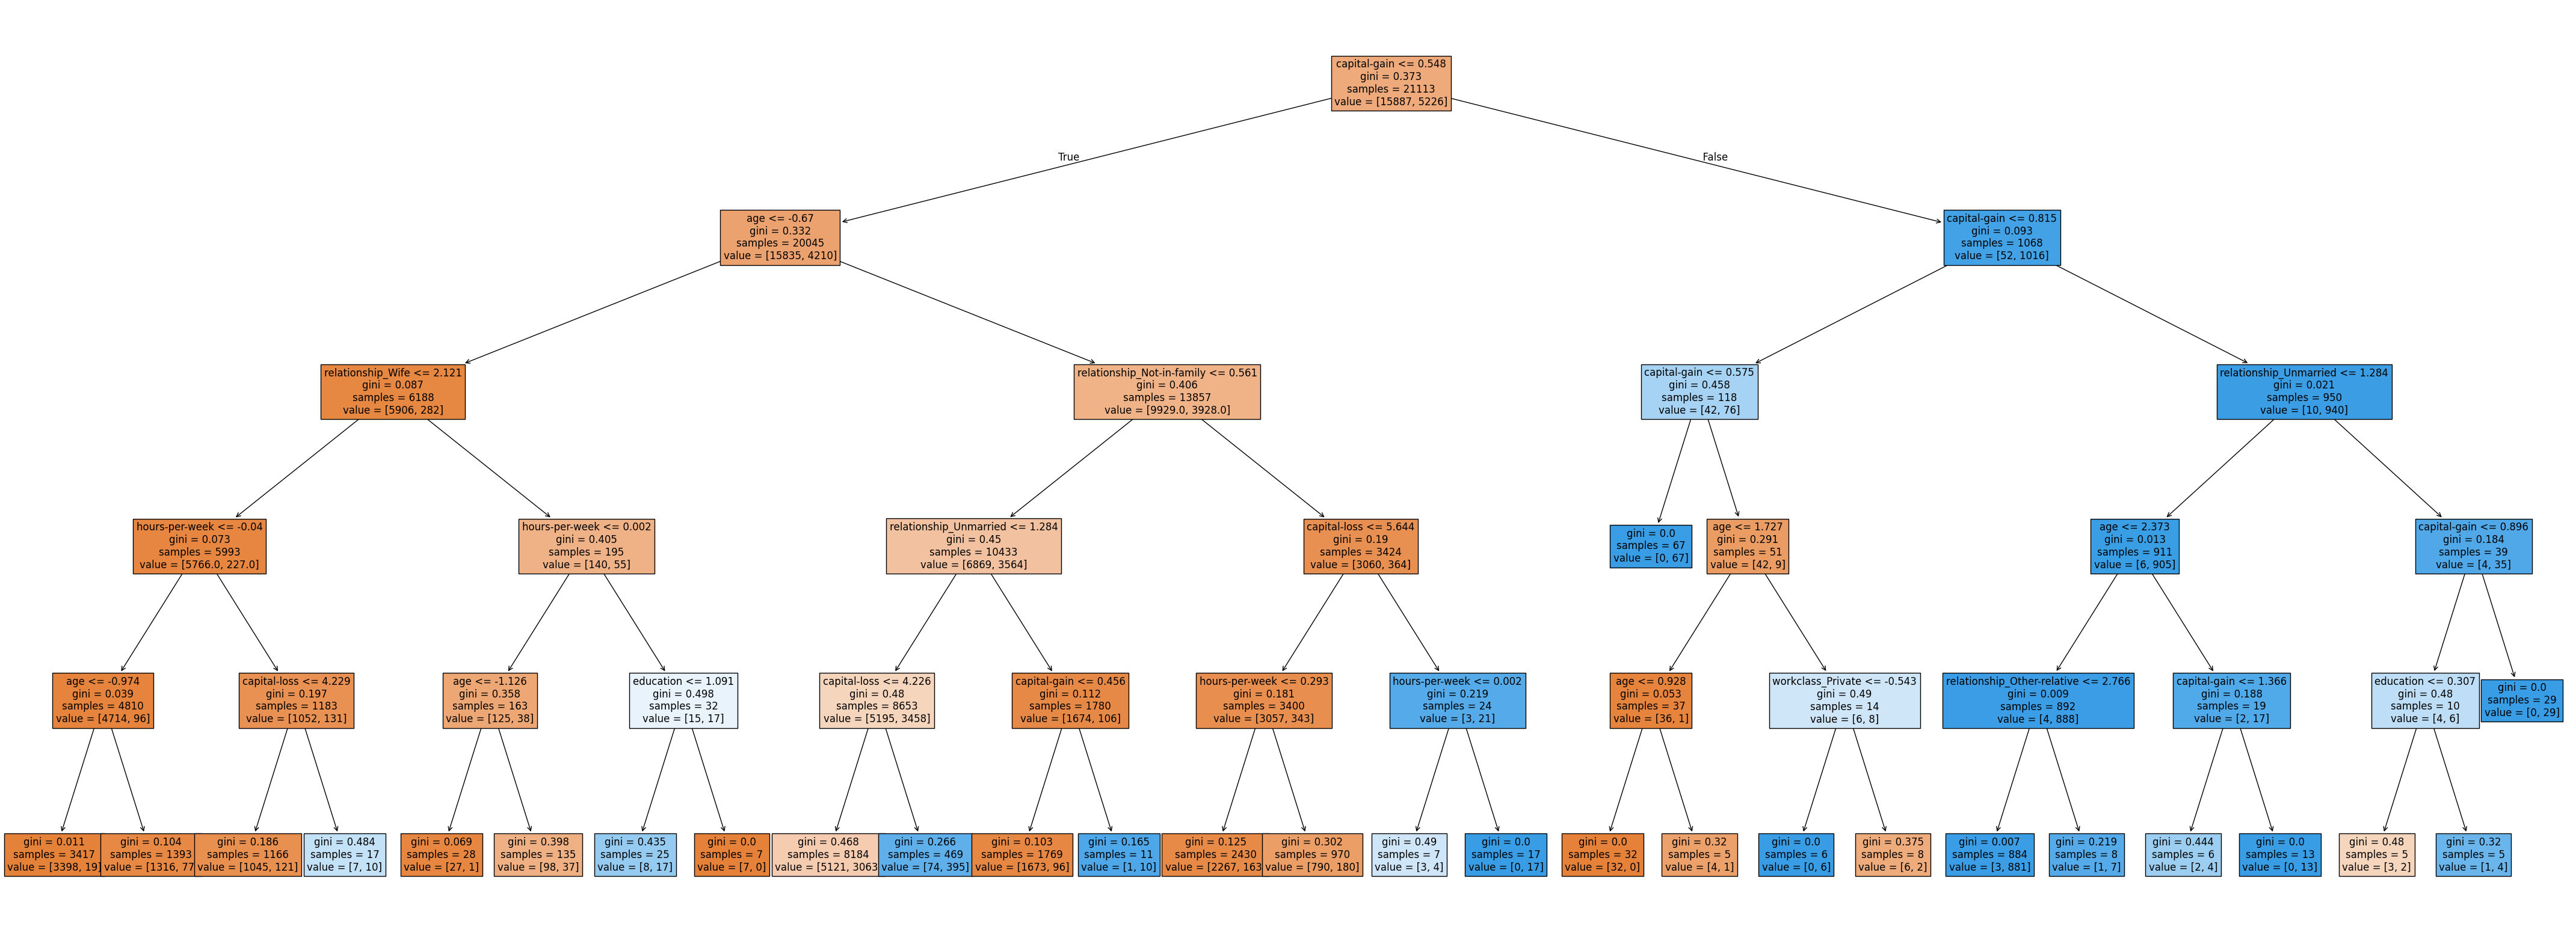

In [123]:
plt.figure(figsize=(55,20))
tree.plot_tree(pruned_tree, feature_names=X_train_scaled.columns, filled=True,fontsize=12)
plt.show()


In [124]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique


<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

As a brush up on data visualisation... make a graph to compare the accuracies you achieved for each of the models you trained and explain which one is the best to perform classification tasks and why?

In [127]:
#write your code here









# **RESEARCH TASK**

Ensemble Models are not only used for classification but also for Regression.Research on the various regression models such as XGBoost Regressor and Random Forest regressor and how are they different from the Linear Regression model we made in Task 2. The best research will be edited and featured on the Synapse Instagram page. Happy coding! :)

The problem with linear regression is that it assumes a straight-line relationship between the features and the house price, which can lead to poor predictions when the relationships are non-linear. It might, for example, assign a fixed price increase per additional bedroom, ignoring interactions like location or house age, so it works well only on simple data but struggles on complex datasets. Random Forest Regressor addresses this by creating bootstrapped samples of the data and building multiple decision trees, where each tree predicts house prices based on splits chosen from a random subset of features using criteria like Gini impurity or entropy. The predictions from all trees are then averaged, which allows the model to capture complex, non-linear relationships and reduces variance. XGBoost Regressor goes further by building trees sequentially, where each subsequent tree focuses on correcting the errors of the previous trees. Each tree contributes to the final price prediction in a weighted, additive manner, and regularization is applied to prevent overfitting. This approach makes XGBoost highly accurate and robust, especially on large or complex datasets with subtle interactions between features.


# **End of Task**

> ©DJS Synapse 2025 - 2026